# Análisis de sentimientos en textos turísticos mexicanos

Este notebook entrena un modelo de clasificación de sentimientos en español usando el dataset de opiniones turísticas. Se incluyen métricas, visualizaciones, análisis de errores y recomendaciones para mejorar el desempeño del modelo.

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import gc


/home/andresmtr/miniconda3/envs/PruebaBRM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carge de datos

In [2]:
raw_data = load_dataset("alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad")
print(raw_data)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 176192
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 75510
    })
})


In [3]:
# Se unen los datos de entrenamiento y test en uno solo para tener mas información

full_data = concatenate_datasets([raw_data["train"], raw_data["test"]])

In [4]:
# Visualizar los primeros ejemplos como si fuera pandas
print("\nPrimeros 5 registros del dataset:")
print(pd.DataFrame(full_data[:5]))


Primeros 5 registros del dataset:
                                                text  label
0  el mejor lugar para comer sushi. excelente lug...      5
1  vista hermosa!. me sorprendió la maravillosa v...      5
2  desastroso. buenas noches,  ante todo explicar...      1
3  todo bien excepto que se niegan a dar vasos de...      3
4  el mejor zoologico de méxico. el ambiente es m...      5


/tmp/ipykernel_100960/1668420484.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_full, x="label", palette="Blues")


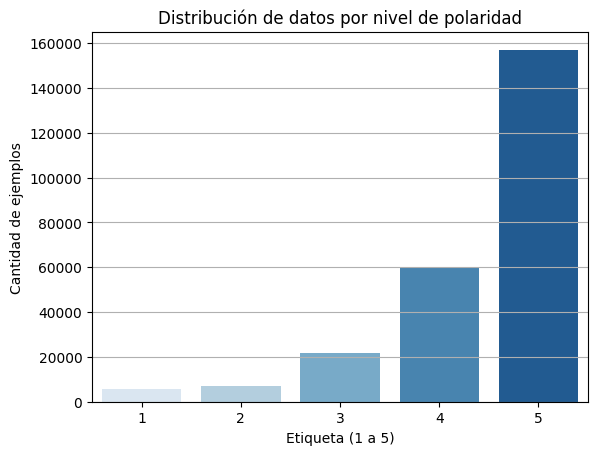

In [5]:
# Convertir a DataFrame para graficar
df_full = pd.DataFrame(full_data)

# Gráfico de barras por etiqueta
sns.countplot(data=df_full, x="label", palette="Blues")

# Personalización del gráfico
plt.title("Distribución de datos por nivel de polaridad")
plt.xlabel("Etiqueta (1 a 5)")
plt.ylabel("Cantidad de ejemplos")
plt.grid(axis="y")
plt.show()

In [6]:
label_counts = df_full['label'].value_counts().sort_index()

# Crear la tabla
tabla_resumen = pd.DataFrame({
    'Etiqueta': label_counts.index,
    'Cantidad de ejemplos': label_counts.values
})

# Mostrar la tabla
tabla_resumen

,Etiqueta,Cantidad de ejemplos
0,1,5772
1,2,6952
2,3,21656
3,4,60227
4,5,157095


In [7]:
del df_full
gc.collect()

170

In [8]:
# Ajustar etiquetas de 1-5 a 0-4
def adjust_labels(example):
    example["label"] = example["label"] - 1
    return example

# Preparar los datos para la tokenizacion

In [9]:
tokenizer = AutoTokenizer.from_pretrained("PlanTL-GOB-ES/roberta-base-bne")

In [10]:
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

In [11]:
# Preprocesamiento
processed = full_data.map(adjust_labels)
processed = processed.map(tokenize, batched=True)
processed.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


In [ ]:
# Aplicar oversampling para balancear clases
labels = [x for x in processed['label']]
counts = Counter(labels)
max_count = max(counts.values())

# Definir cuántos ejemplos extra deseas por clase (controlado)
extra_per_class = {
    0: 40000,
    1: 35000,
    2: 20000,
    3: 10000
}

balanced_data = []

# Agrupar registros por clase
for label in range(5):
    class_samples = [processed[i] for i in range(len(processed)) if processed[i]['label'] == label]
    
    # Agregar los originales
    balanced_data.extend(class_samples)

    # Oversample solo si se especifica
    if label in extra_per_class:
        extra_count = extra_per_class[label]
        sampled = random.choices(class_samples, k=extra_count)  # random.choices en vez de np.random.choice
        balanced_data.extend(sampled)

# Crear el dataset balanceado
balanced_dataset = Dataset.from_list(balanced_data)

In [ ]:
# Convertir a DataFrame para graficar
df_full = pd.DataFrame(balanced_dataset)

label_counts = df_full['label'].value_counts().sort_index()

# Crear la tabla
tabla_resumen = pd.DataFrame({
    'Etiqueta': label_counts.index,
    'Cantidad de ejemplos': label_counts.values
})

# Mostrar la tabla
tabla_resumen

In [ ]:
del df_full
gc.collect()

159

In [ ]:
balanced_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [ ]:
# Separar datos
train_data, test_data = balanced_dataset.train_test_split(test_size=0.2, seed=42).values()

In [ ]:
# DataLoaders

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

# Cargar modelo preeentrenado

In [ ]:
## Se toma este modelo, ayq ue fue entrenado para que funcione correctamente con el español

model = AutoModelForSequenceClassification.from_pretrained(
    "PlanTL-GOB-ES/roberta-base-bne",
    num_labels=5  # Etiquetas de 1 a 5
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at PlanTL-GOB-ES/roberta-base-bne and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Configurar optmizador, la perdida y uso de CUDA

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
num_training_steps = len(train_loader) * 5  # 5 = número de épocas
scheduler = get_scheduler(
    "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [ ]:
# Activar CUDA Launch Blocking para depuración
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [ ]:
# Verificacion del uso de cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50262, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

# Entrenamiento

In [ ]:
train_losses = []
model.train()
for epoch in range(3):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    epoch_loss = 0
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))


Epoch 1:   0%|          | 0/15836 [00:00<?, ?it/s]


AttributeError: 'list' object has no attribute 'to'

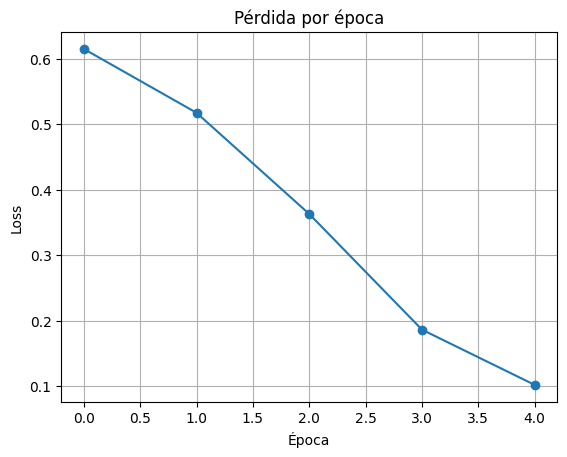

In [ ]:
# Paso 5: Visualización de la pérdida
plt.plot(train_losses, marker='o')
plt.title('Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Evaluación

In [ ]:
model.eval()
preds, trues = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        preds.extend(predictions.cpu().numpy())
        trues.extend(labels.cpu().numpy())

# Clasificación
print(classification_report(trues, preds, digits=3))

              precision    recall  f1-score   support

           0      0.702     0.597     0.645      1134
           1      0.439     0.416     0.428      1431
           2      0.579     0.570     0.574      4321
           3      0.506     0.525     0.515     12030
           4      0.842     0.838     0.840     31425

    accuracy                          0.723     50341
   macro avg      0.613     0.589     0.600     50341
weighted avg      0.724     0.723     0.723     50341



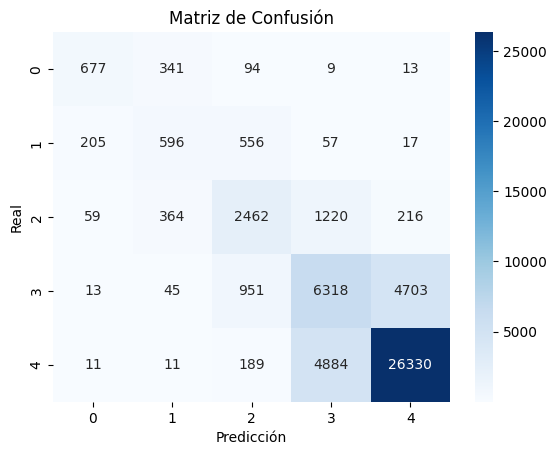

In [ ]:
# Matriz de confusión
cm = confusion_matrix(trues, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
# Mostrar comparaciones correctas

correct = [(p, t, s) for p, t, s in zip(preds, trues, test_data['text']) if p == t]

print("\nEjemplos de clasificaciones correctas:\n")
for p, t, s in correct[:200]:
    print(f"Texto: {s[:100]}...\nPredicho: {p} | Real: {t}\n")


In [ ]:
# Mostrar comparaciones incorractas

wrong = [(p, t, s) for p, t, s in zip(preds, trues, test_data['text']) if p != t]
print("\nEjemplos de errores de clasificación:\n")
for p, t, s in wrong[:200]:
    print(f"Texto: {s[:6]}...\nPredicho: {p} | Real: {t}\n")


Ejemplos de errores de clasificación:

Texto: impresionante. espeluznante, y deja un mal sabor de boca si eres sensible con el tema, así que mejor...
Predicho: 4 | Real: 3

Texto: para nada les recomiendo este hotel.. está bien ubicado pero hay más hoteles buenos en la zona. los ...
Predicho: 1 | Real: 0

Texto: super. mi lugar favorito para comer. me encanta la vista del océano. posiblemente necesita girar un ...
Predicho: 4 | Real: 3

Texto: a los amantes de la aventura y la arqueologia. es una ruta muy cansada pero vale la pena, puedes ir ...
Predicho: 3 | Real: 4

Texto: calidad precio genial. en nuestra primera noche en la habana cenamos en este restaurante, la verdad ...
Predicho: 4 | Real: 3

Texto: bonito lugar para una caminata. es un bonito lugar para una caminata, por la tarde7 noche, se parece...
Predicho: 3 | Real: 4

Texto: fantástica. ha cambiado de los años. se nota importante piezas de arte indicando la historia de este...
Predicho: 4 | Real: 3

Texto: gran comida aut

In [ ]:
model.save_pretrained("modelo-turismo-sentimientos")
tokenizer.save_pretrained("modelo-turismo-sentimientos")

('modelo-turismo-sentimientos/tokenizer_config.json',
 'modelo-turismo-sentimientos/special_tokens_map.json',
 'modelo-turismo-sentimientos/vocab.json',
 'modelo-turismo-sentimientos/merges.txt',
 'modelo-turismo-sentimientos/added_tokens.json',
 'modelo-turismo-sentimientos/tokenizer.json')

# Comentarios finales: